In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
deliveries=pd.read_csv("deliveries.csv")
matches=pd.read_csv("matches.csv")

In [3]:
matches.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Royal Challengers Bengaluru      9
Rising Pune Supergiant           7
Rising Pune Supergiants          7
Kochi Tuskers Kerala             7
Name: count, dtype: int64

# Data cleanig

In [6]:
matches=matches[matches['city'] != 'unknown']

In [7]:
matches.replace({'Rising Pune Supergiants' : 'Rising Pune Supergiant'}, inplace=True)
matches.replace({'Royal Challengers Bengaluru' :'Royal Challengers Bangalore'},inplace=True)

In [9]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    144
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Pune Warriors                   23
Lucknow Super Giants            23
Gujarat Titans                  21
Gujarat Lions                   16
Rising Pune Supergiant          14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [10]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

In [11]:
deliveries.replace({'Rising Pune Suoergiant' : 'Rising Pune Supergiant'}, inplace=True)
deliveries.replace({'Royal Challengers Bengaluru' : 'Royal Challengers Bangalore'}, inplace=True)

In [12]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Royal Challengers Bangalore    30023
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

In [13]:
matches['city'].isnull().sum()

np.int64(52)

In [14]:

matches['method'].isna().sum()

np.int64(1075)

In [15]:
matches['city'].fillna('unknown',inplace=True)

/var/folders/5g/y9p_z08d31x4xz4f863vcf1r0000gn/T/ipykernel_61709/574805598.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('unknown',inplace=True)


In [16]:
matches['city'].isnull().sum()

np.int64(0)

In [17]:
matches['method'].fillna('not DL',inplace=True)

/var/folders/5g/y9p_z08d31x4xz4f863vcf1r0000gn/T/ipykernel_61709/1873666747.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['method'].fillna('not DL',inplace=True)


In [18]:
matches['method'].isna().sum()

np.int64(0)

# Success rate of teams in Home Ground

In [19]:
success = matches['winner'].value_counts()
success

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    123
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [20]:
matches_played = pd.concat([matches['team1'],matches['team2']]).value_counts()
matches_played

Mumbai Indians                 261
Royal Challengers Bangalore    255
Kolkata Knight Riders          251
Chennai Super Kings            238
Rajasthan Royals               221
Kings XI Punjab                190
Sunrisers Hyderabad            182
Delhi Daredevils               161
Delhi Capitals                  91
Deccan Chargers                 75
Punjab Kings                    56
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Rising Pune Supergiant          30
Gujarat Lions                   30
Kochi Tuskers Kerala            14
Name: count, dtype: int64

In [21]:
success_rate = (success/matches_played * 100).round(1)
success_rate.sort_values(ascending=False)


Gujarat Titans                 62.2
Chennai Super Kings            58.0
Mumbai Indians                 55.2
Lucknow Super Giants           54.5
Delhi Capitals                 52.7
Kolkata Knight Riders          52.2
Rajasthan Royals               50.7
Rising Pune Supergiant         50.0
Sunrisers Hyderabad            48.4
Royal Challengers Bangalore    48.2
Kings XI Punjab                46.3
Gujarat Lions                  43.3
Kochi Tuskers Kerala           42.9
Punjab Kings                   42.9
Delhi Daredevils               41.6
Deccan Chargers                38.7
Pune Warriors                  26.1
Name: count, dtype: float64

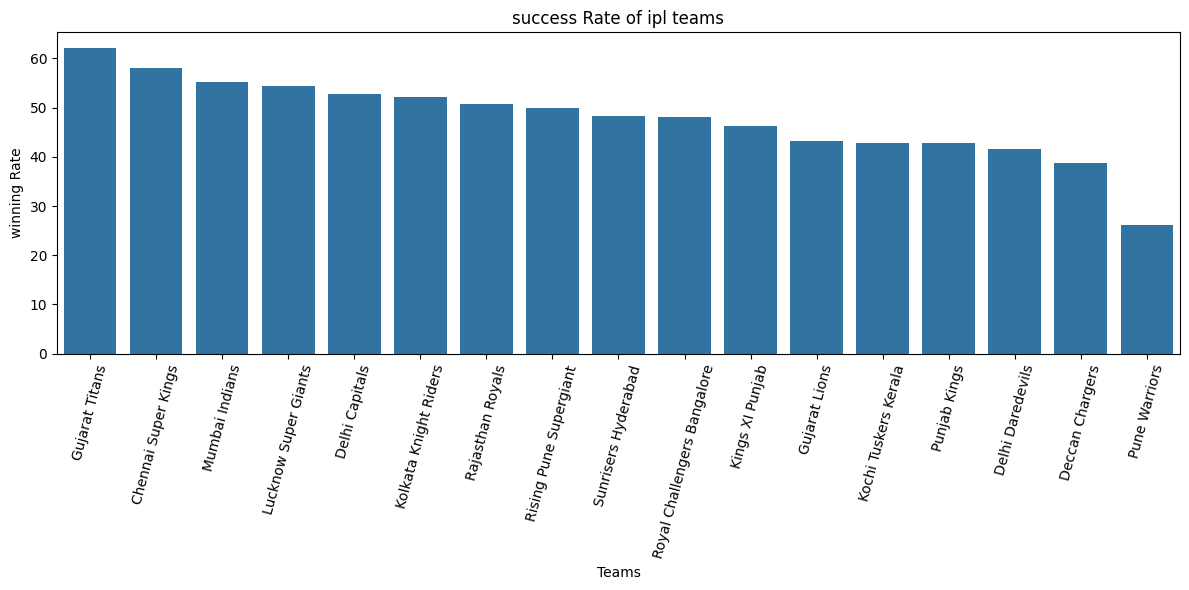

In [22]:
success_rate = (success/matches_played * 100).round(1)
success_rate=success_rate.sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=success_rate.index,y=success_rate.values)
plt.title("success Rate of ipl teams")
plt.xlabel("Teams")
plt.ylabel("winning Rate")
plt.xticks(rotation = 75)
plt.tight_layout()

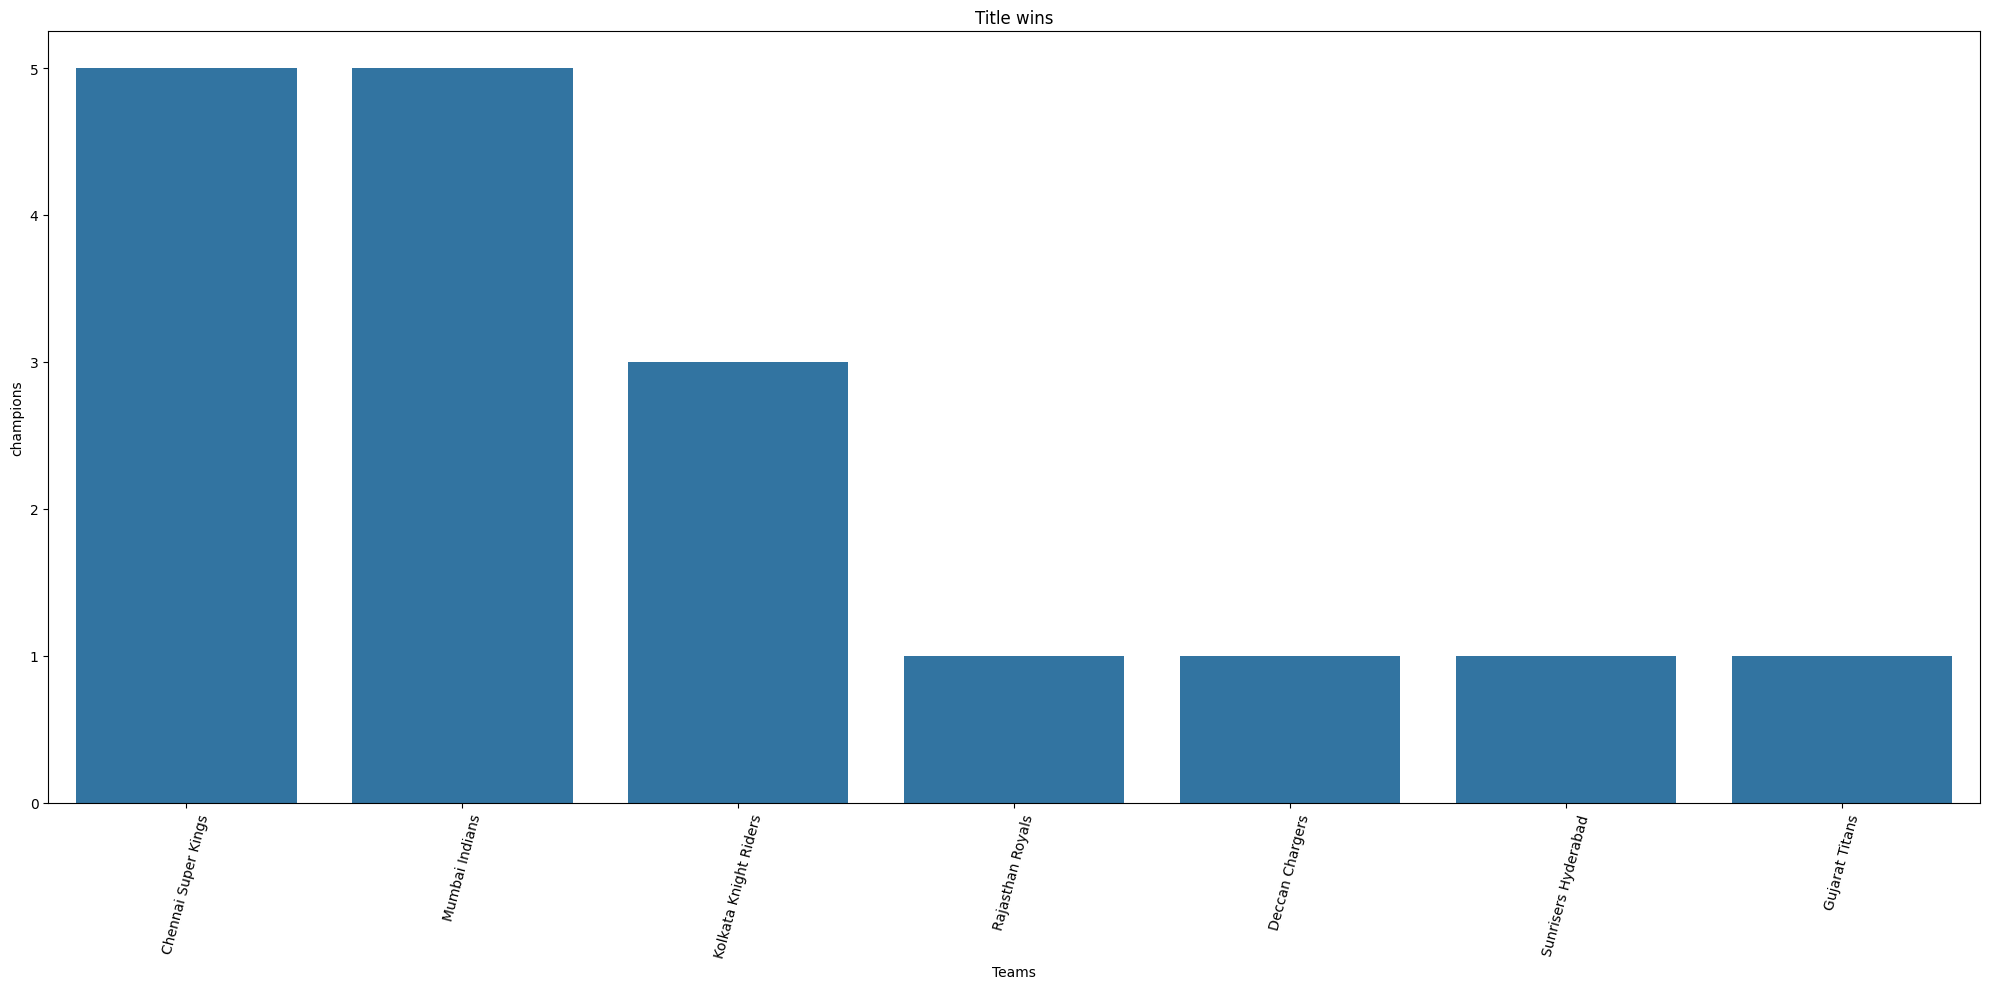

In [23]:
champions=matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()
plt.figure(figsize=(20,10))
sns.barplot(x=champions.index,y=champions.values)
plt.title("Title wins")
plt.xlabel("Teams")
plt.ylabel("champions")
plt.xticks(rotation = 75)
plt.tight_layout()

In [24]:
mostRuns=deliveries.groupby('batter')['batsman_runs'].sum()
Top_batsmen=mostRuns.sort_values(ascending=False)[:10]

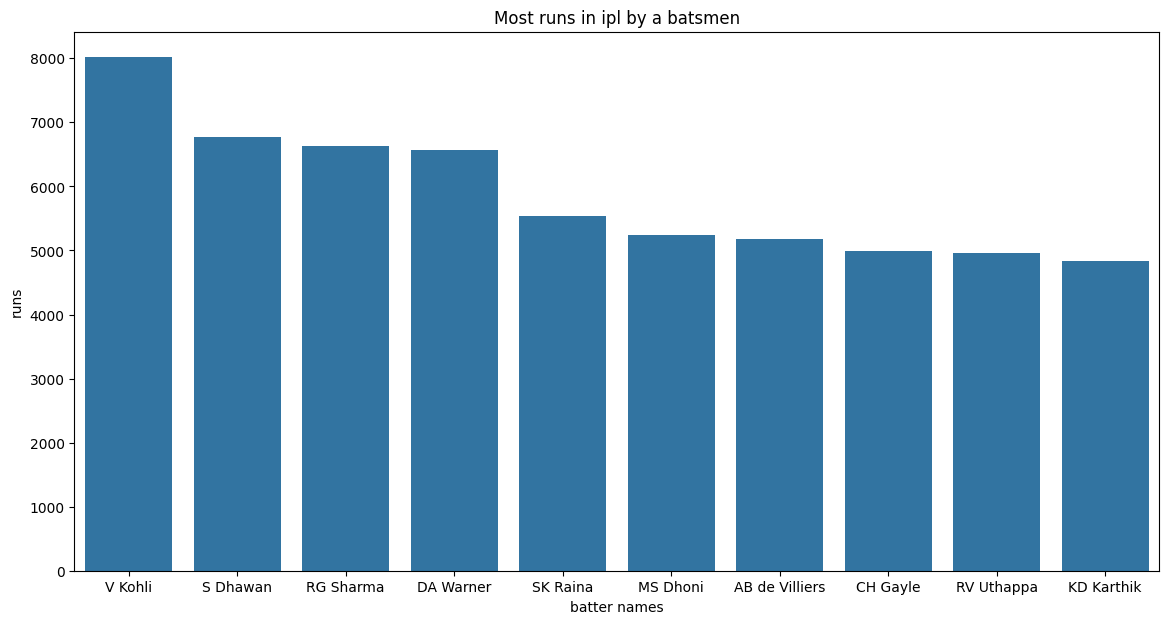

In [25]:
Top_batsmen
plt.figure(figsize=(14,7))
sns.barplot(x=Top_batsmen.index,y=Top_batsmen.values)
plt.title("Most runs in ipl by a batsmen")
plt.xlabel("batter names")
plt.ylabel("runs")
plt.show()

# TOP bowling wickets

In [26]:
topBowlers=deliveries[deliveries['dismissal_kind'] != 'run out']
mostWickets=topBowlers.groupby(['bowler'])['dismissal_kind'].count().reset_index(name='wickets')
mostWickets=mostWickets.sort_values(by='wickets' ,ascending=False)[:10]
mostWickets



,bowler,wickets
524,YS Chahal,205
348,PP Chawla,192
119,DJ Bravo,183
355,R Ashwin,181
71,B Kumar,181
446,SP Narine,180
8,A Mishra,174
438,SL Malinga,170
193,JJ Bumrah,168
373,RA Jadeja,160


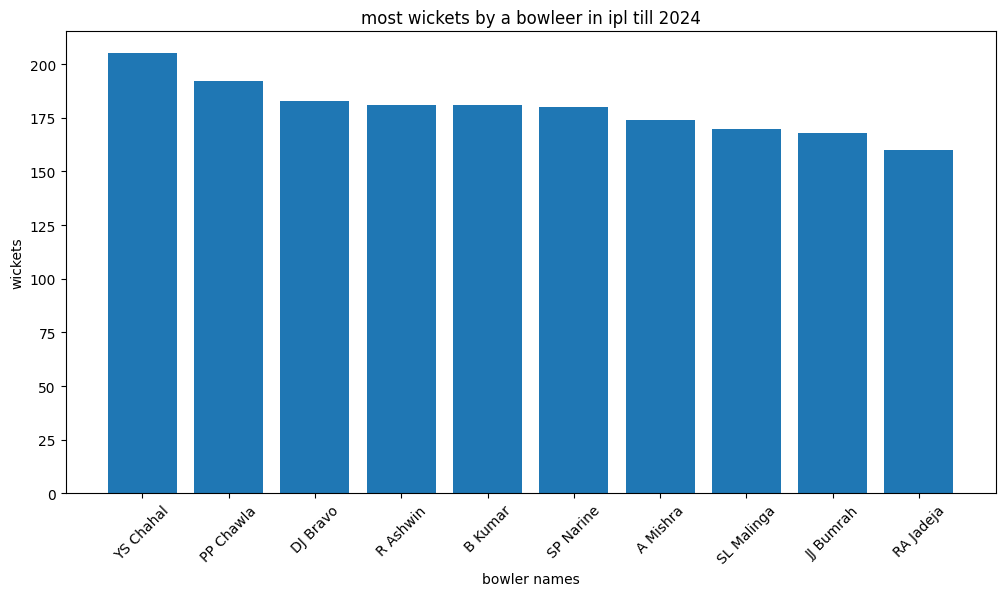

In [27]:
mostWickets
plt.figure(figsize=(12,6))

plt.bar(
    mostWickets['bowler'],
    mostWickets['wickets']
)

plt.xticks(rotation=45)
plt.title("most wickets by a bowleer in ipl till 2024")
plt.xlabel("bowler names")
plt.ylabel("wickets")
plt.show()

# Most matches played in city's

In [28]:
city_matches=matches['city'].value_counts().reset_index(name='matches played')
city_matches=city_matches[:10]
city_matches


,city,matches played
0,Mumbai,173
1,Kolkata,93
2,Delhi,90
3,Chennai,85
4,Hyderabad,77
5,Bangalore,65
6,Chandigarh,61
7,Jaipur,57
8,unknown,52
9,Pune,51


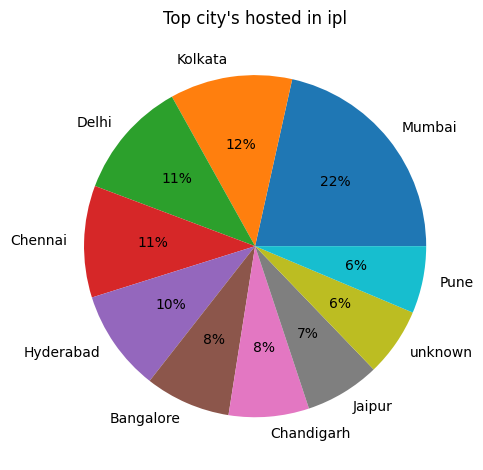

In [29]:
plt.Figure(figsize=(8,8))
plt.pie(city_matches['matches played'],labels=city_matches['city'],autopct='%1.0f%%')
plt.title("Top city's hosted in ipl")
plt.tight_layout()
plt.show()

# Top dismissal kinds

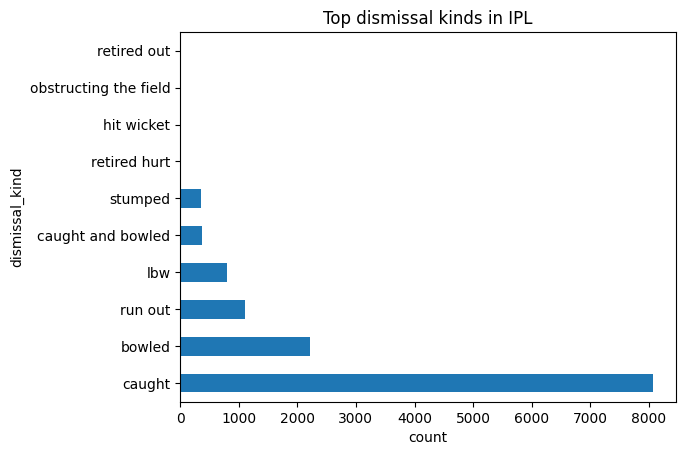

In [30]:
dismissals=deliveries['dismissal_kind'].value_counts()
dismissals.plot(kind='barh')
plt.title("Top dismissal kinds in IPL")
plt.xlabel("count")
plt.show()

Text(0, 0.5, 'count')

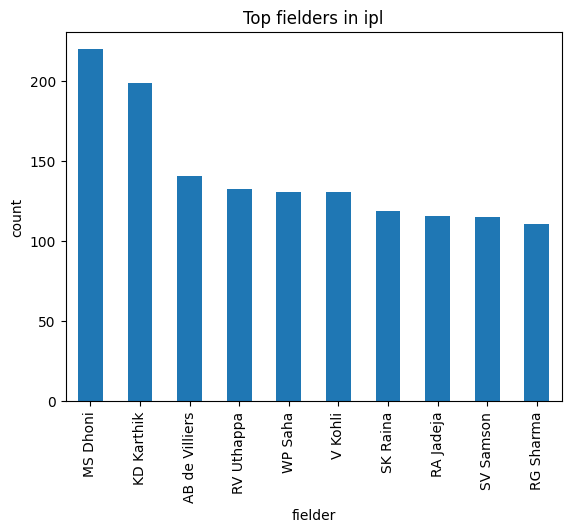

In [31]:
deliveries['fielder'].value_counts()[:10].plot(kind='bar')
plt.title("Top fielders in ipl")
plt.ylabel('count')

# TOSS

Text(0.5, 1.0, 'Toss decision')

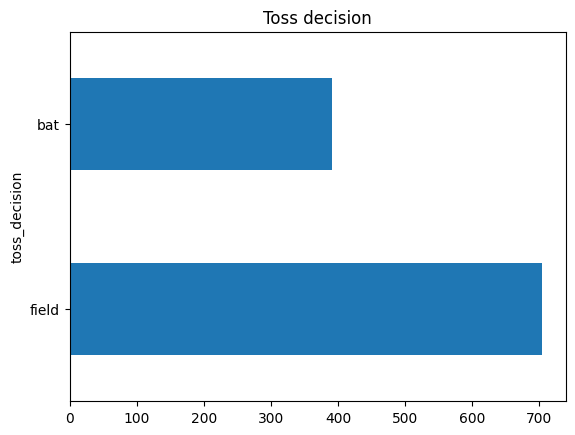

In [32]:
matches['toss_decision'].value_counts().plot(kind='barh')
plt.title('Toss decision')